In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["axes.grid"] = False
sc.settings.set_figure_params(dpi=80, dpi_save=180, vector_friendly=True, transparent=True)

In [2]:
results= "./pnec_anndata_082023/pNEC_updated_annot_07082023.h5ad"
adata= sc.read_h5ad(results)

adata.obs['Cell states'] = (adata.obs["Cell states"].map(lambda x: {"Neuroendocrine EEC-like01": "Amphicrine progenitor-like",
                    "Neuroendocrine EEC-like02": "Neuroendocrine", 
                    "Neuroendocrine HSP+": "Neuroendocrine HSP+ (hypoxic)"}.get(x, x)).astype("category"))

adata.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Amphicrine progenitor-like',
       'Neuroendocrine', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like',
       'Stroma (normal)', 'Lymphocytes', 'Macrophages'],
      dtype='object')

In [3]:
#Cell type categories: 
adata.obs['cell_types'].cat.categories

Index(['Immune (non-tumor)', 'NE', 'NE (acinar)', 'Stromal (mixed)',
       'Stromal-like NE'],
      dtype='object')

In [4]:
#Map the cell types (merge & rename) to reflect the correct annotations: 
#Based on tentative cell type annotations 
adata.obs['cell_types'] = (adata.obs["cell_type_semifinal_v4"].map(lambda x: {"Acinar_like_NET01": "NE (acinar)",
    "Acinar_like_NET02": "NE (acinar)", "BRCA1/FANCA_NETp": "NE", 
    "BRCA1/FANCA_NETp (acinar like)": "NE (acinar)", 
    "Exo_glandular_mixed01": "NE (acinar)", "Exo_glandular_mixed02": "NE (acinar)",
    "HSPpos_NET": "NE", "GIPR+ EEC like": "NE",
    "Smooth muscle like tumors (SMT)": "Amphicrine progenitor-like", 
    'Stromal1': 'Stromal-like NE', 'Stromal2': 'Stromal (mixed)', 
    "Lymphocytes (non-tumor)": "Immune (non-tumor)", 
    "Macrophages (non-tumor)": "Immune (non-tumor)"}.get(x, x)).astype("category"))

adata.obs['Cell types']= adata.obs['cell_types']
adata.obs['Cell types'].cat.categories

Index(['Amphicrine progenitor-like', 'Immune (non-tumor)', 'NE', 'NE (acinar)',
       'Stromal (mixed)', 'Stromal-like NE'],
      dtype='object')

In [5]:
#Rename: 
adata.obs['Cell types']= (adata.obs["cell_types"].map(lambda x: {"NE": "Neuroendocrine",
            "NE (acinar)": "Amphicrine acinar", "Stromal-like NE": "Neuroendocrine", "Stromal (mixed)": "Stroma (normal)", 
            "Immune (non-tumor)": "Immune"}.get(x, x)).astype("category"))

adata.obs['Cell types']= adata.obs['Cell types'].cat.reorder_categories(['Neuroendocrine', 'Amphicrine progenitor-like', 
                            'Amphicrine acinar',  'Stroma (normal)', 'Immune'])

adata.obs['Cell types'].cat.categories

Index(['Neuroendocrine', 'Amphicrine progenitor-like', 'Amphicrine acinar',
       'Stroma (normal)', 'Immune'],
      dtype='object')

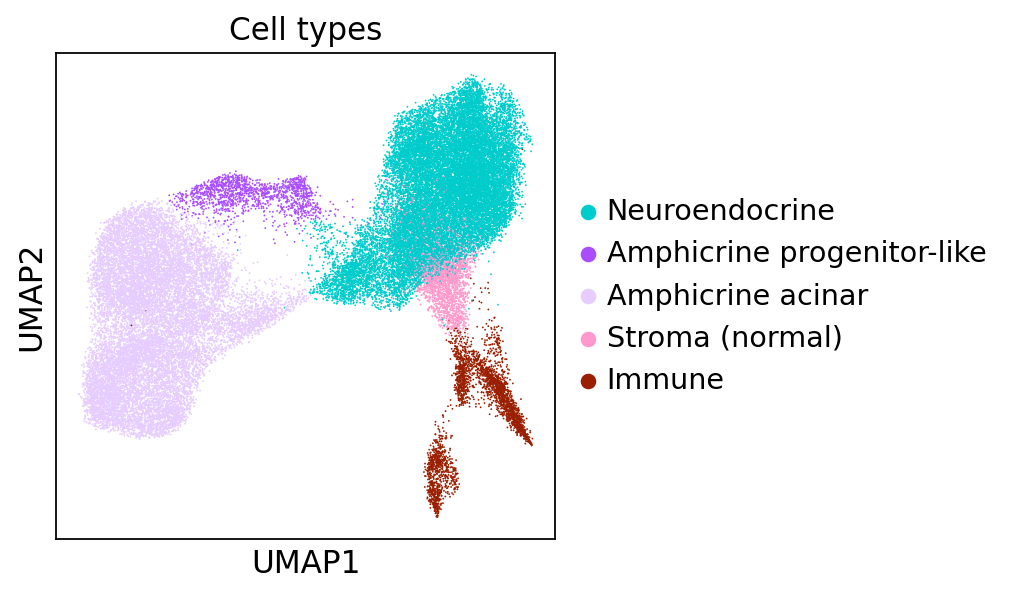

In [6]:
#Cell type UMAP as shown in Figure 1: 
adata.uns['Cell types_colors']= ['#00cccc', '#a94dff', '#e6ccff', '#ff99cc','#991f00']

#Bertram asked to assign a different color code to "stroma": figure2B. 
sc.pl.umap(adata, color = ['Cell types'])

#### Supplementary Figure 1e: Density estimation on UMAP embedding

To visualize the distribution of cells from each sample across the shared UMAP embedding, per-sample cell density was estimated using Scanpy's embedding_density function (sc.tl.embedding_density), which computes a Gaussian kernel density estimate (KDE) over the two-dimensional UMAP coordinates for each sample group independently. Each sample's density values were then min-max normalized to a scale of 0–1, allowing relative density patterns to be compared across samples despite differences in cell number. The resulting density was visualized using sc.pl.embedding_density, with the full dataset shown in grey as a reference background and sample-specific density overlaid as a color gradient from yellow (low density) to dark red (high density).

In [7]:
#Save original colors before renaming
original_colors = dict(zip(adata.obs['PatientID'].cat.categories, adata.uns['PatientID_colors']))

#Define the mapping for renaming
rename_dict = {
    "P07": "P1",
    "P018": "P2",
    "P019": "P3",
    "P021": "P4",
    "P024 (acinar-like)": "P5 (acinar-like)"
} #renamed the original Clinical IDs. 

#Apply renaming to the 'PatientID' column
adata.obs['PatientID'] = adata.obs['PatientID'].replace(rename_dict)
adata.obs['PatientID'] = adata.obs['PatientID'].astype("category")
adata.obs['PatientID'].value_counts()

P5 (acinar-like)    19497
P1                   8768
P2                   8314
P3                   5580
P4                   2856
Name: PatientID, dtype: int64

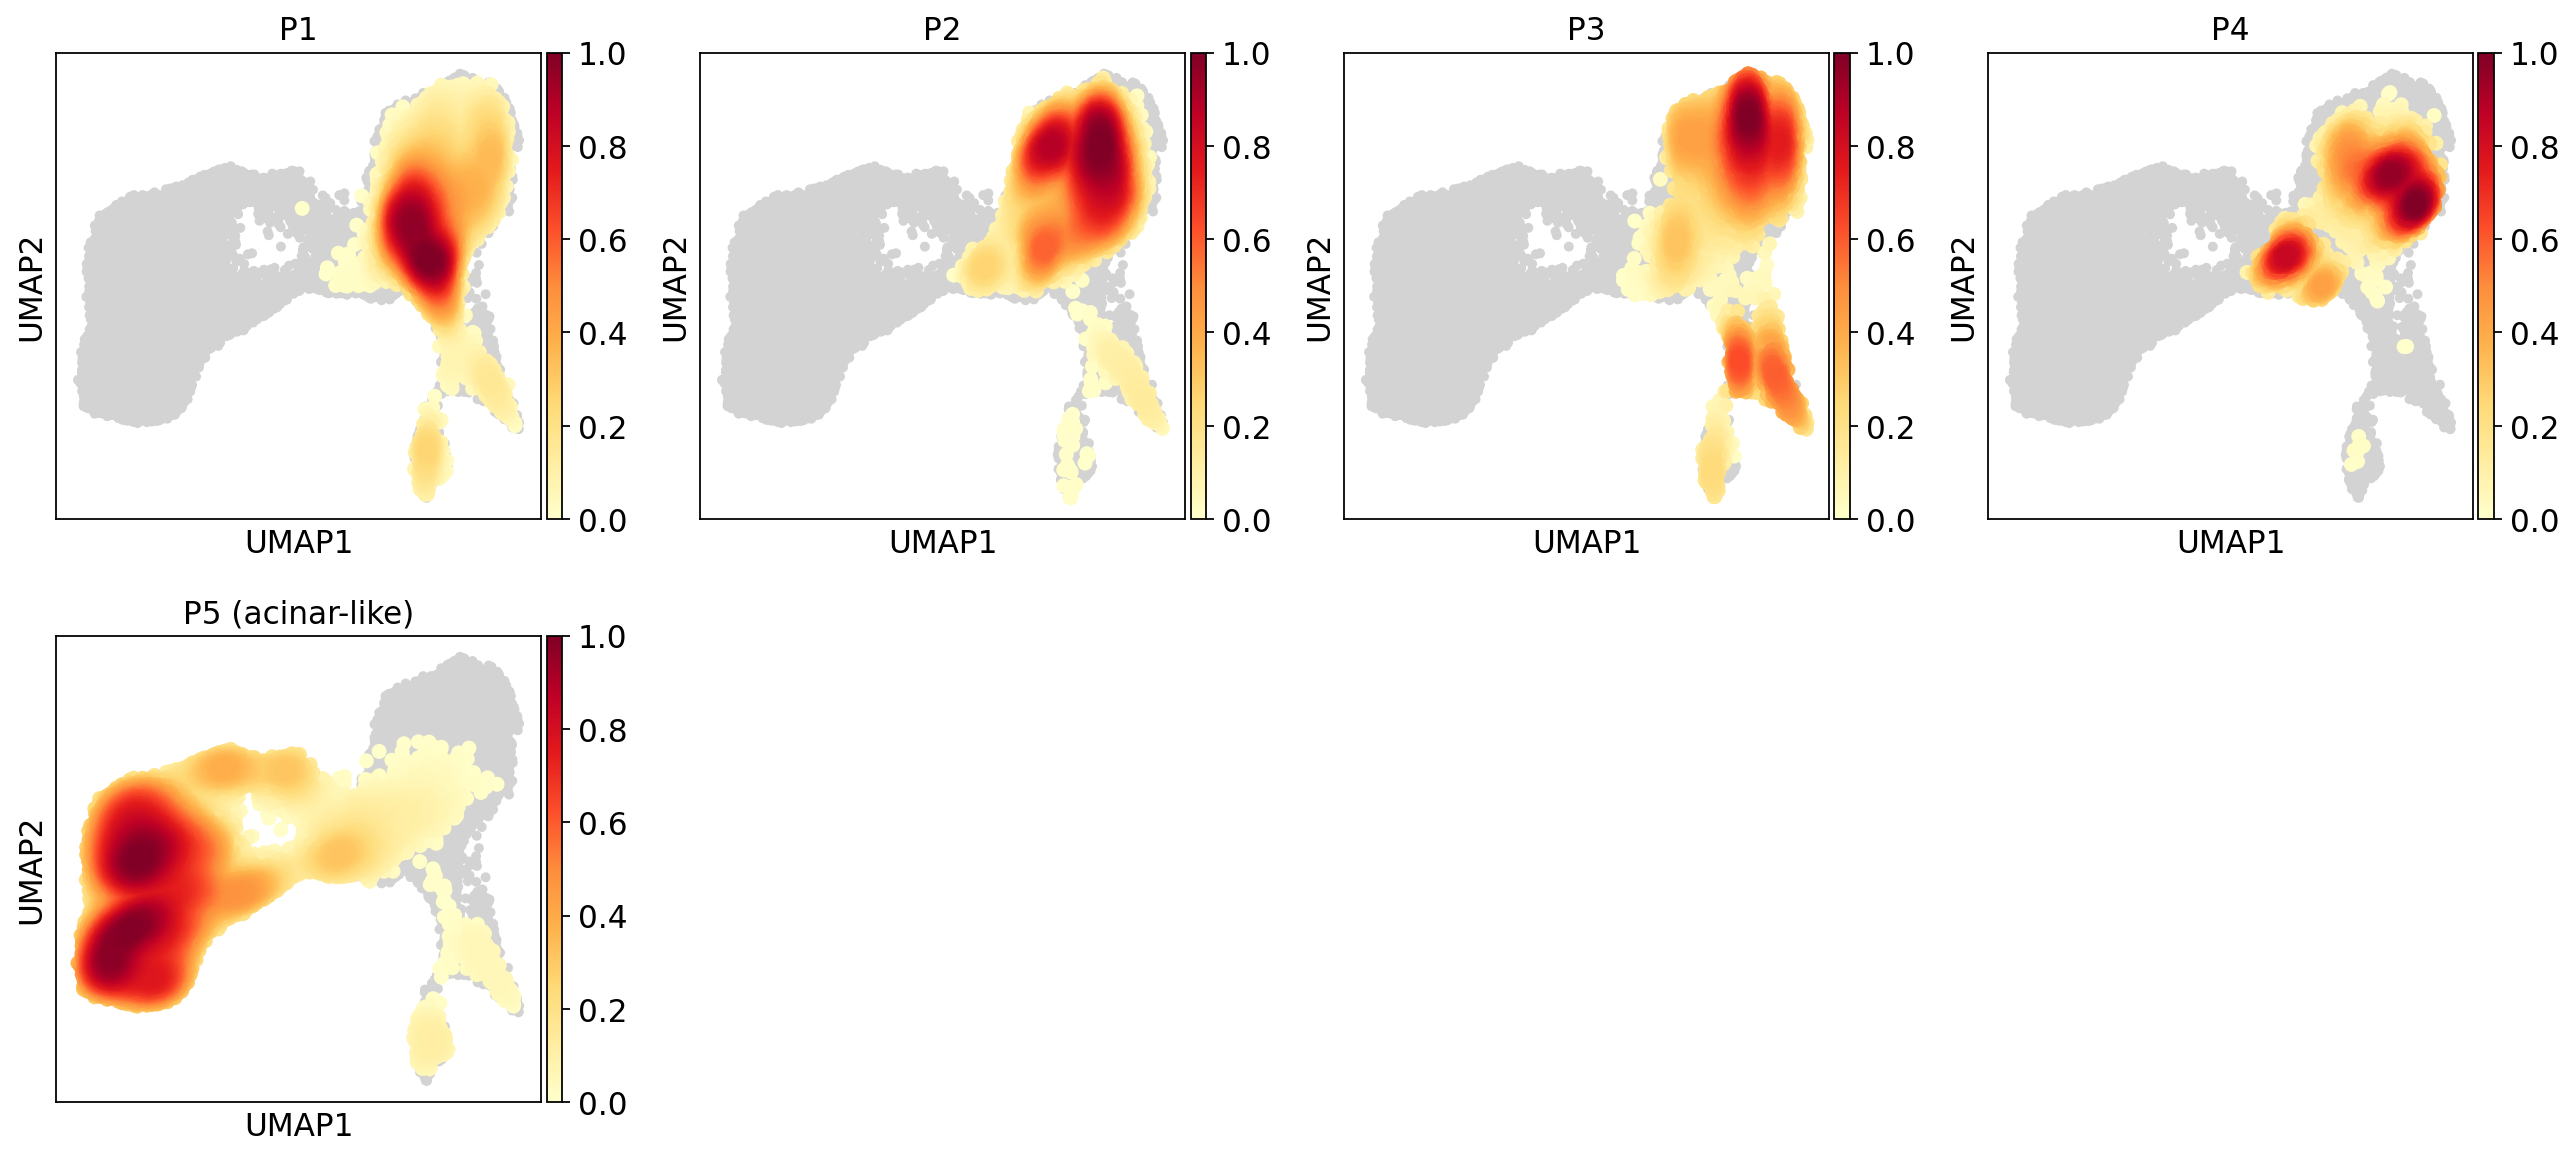

In [8]:
#KDE: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.embedding_density.html
sc.tl.embedding_density(adata, basis='umap', groupby='PatientID')

sc.pl.embedding_density(adata, basis='umap', 
                        key='umap_density_PatientID', group=['P1','P2','P3','P4','P5 (acinar-like)'],
                       save= "_SupplFigure1E_KDE_per_sample_10032025.pdf")

#### Supplementary Figure 1f: Cell type composition across P1-P5 samples 

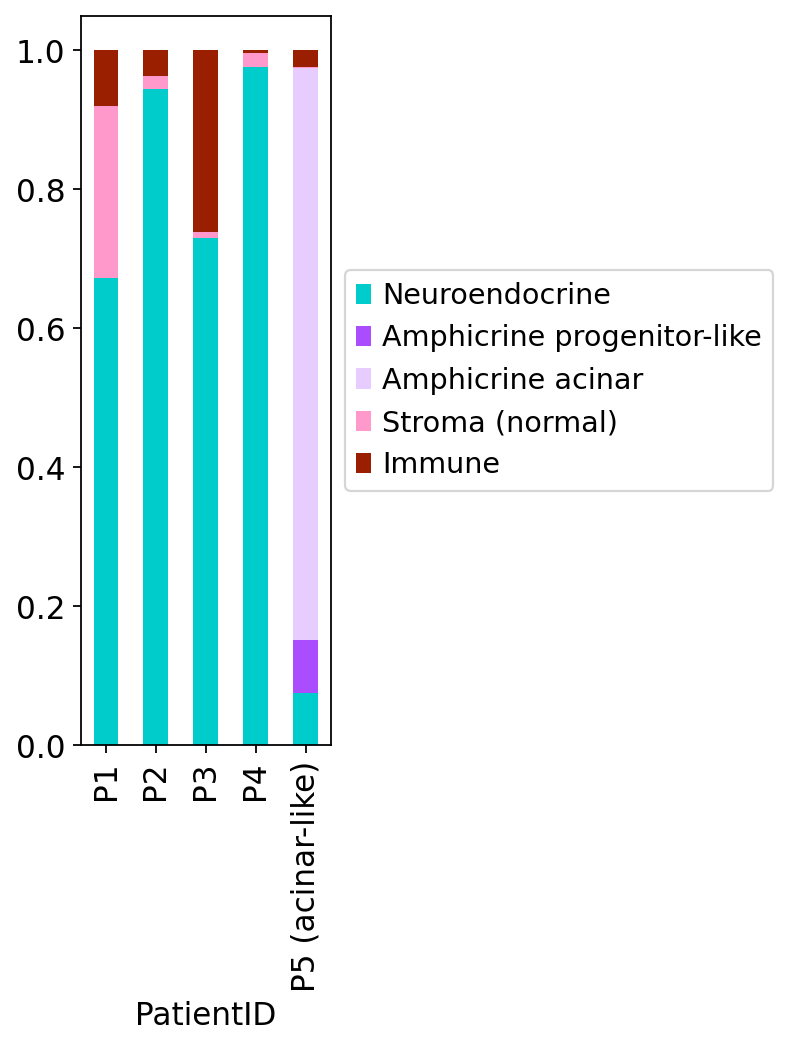

In [9]:
#Plot on a cell type level:
df= pd.crosstab(adata.obs['PatientID'], adata.obs['Cell types'], normalize= "index")

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (2,6)

pl = df.plot(kind="bar", stacked=True, rot=90, color= ['#00cccc', '#a94dff', '#e6ccff', '#ff99cc','#991f00'])
pl.grid(False)
pl.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('Cell_types_composition_v2_10032025.pdf')

In [10]:
#Normalize the data:
adata_norm= adata.raw.to_adata()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

#### Supplementary Figure 1g: Broad cell type markers 

In [11]:
sc.tl.rank_genes_groups(adata_norm, groupby='Cell types', method='wilcoxon')
sc.tl.dendrogram(adata_norm, groupby= "Cell types")

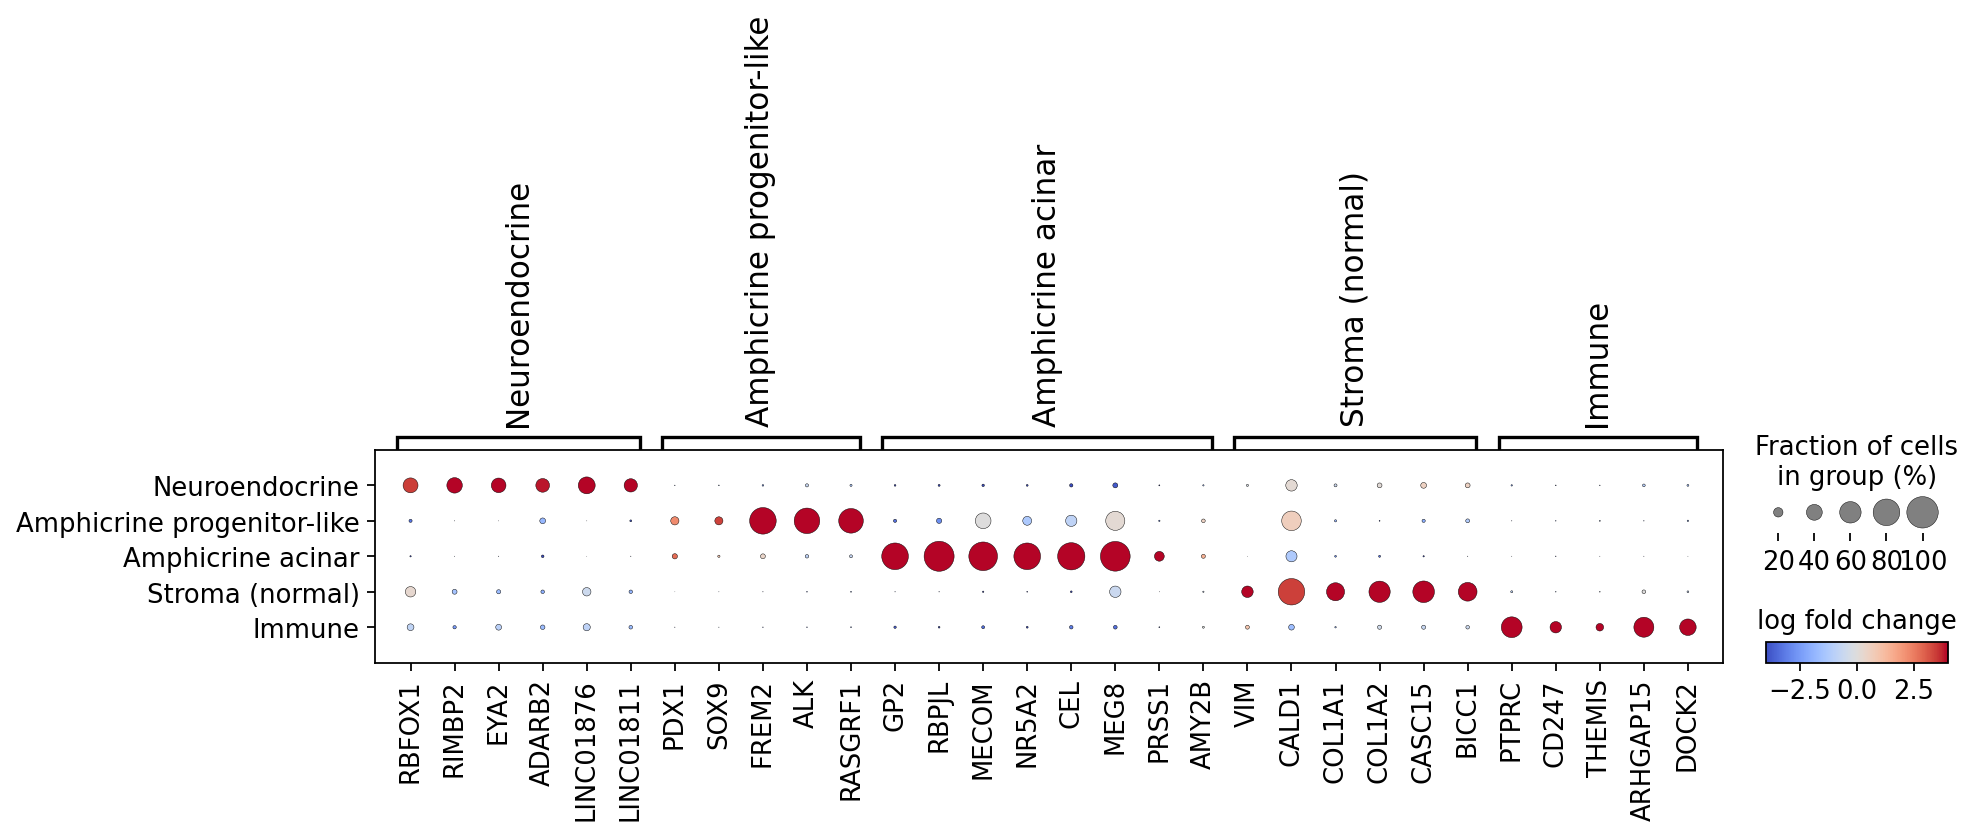

In [12]:
#Reference: Fig4.2_celltypes_markers_29022024.ipynb (line-40; after refining markerss)
var_names = {'Neuroendocrine': ['RBFOX1', 'RIMBP2', 'EYA2', 'ADARB2', 'LINC01876', 'LINC01811'],
            'Amphicrine progenitor-like': ['PDX1', 'SOX9', 'FREM2', 'ALK', 'RASGRF1'],
            'Amphicrine acinar': ['GP2', 'RBPJL', 'MECOM', 'NR5A2', 'CEL', 'MEG8', 'PRSS1', 'AMY2B'],
            'Stroma (normal)': ['VIM', 'CALD1', 'COL1A1', 'COL1A2', 'CASC15', 'BICC1'],
            'Immune': ['PTPRC', 'CD247', 'THEMIS', 'ARHGAP15', 'DOCK2']}

sc.pl.rank_genes_groups_dotplot(
    adata_norm,
    var_names=var_names,
    values_to_plot="logfoldchanges",
    cmap='coolwarm',
    vmin=-4,
    vmax=4,
    min_logfoldchange=3,
    dendrogram=False, 
    colorbar_title='log fold change', save= "_SupplFigure1G_celltypes_logFC_DP_10032025.pdf")